# 📚 Section 5. Distribution Charts — Histogram / KDE / Box Plot / Violin Plot
> 섹션 5. 분포 차트 — Histogram / KDE / Box Plot / Violin Plot

---
# 🎯 Learning Objective · 학습 목표
Today I want to learn: · 오늘 배우고 싶은 것:
- [x] Read a Histogram's shape (center, skew, modes, outliers) and know how the bins parameter changes what you see  
Histogram의 모양(중심, 치우침, 최빈값, 이상치)을 읽고 bins 파라미터가 무엇을 바꾸는지 알기
- [x] Draw a KDE curve and explain how its bandwidth is the smooth-curve equivalent of a Histogram's bins  
KDE 곡선을 그리고, bandwidth가 Histogram의 bins에 해당하는 개념임을 설명하기
- [x] Read a Box Plot's 5 summary numbers and calculate its IQR-based outlier fence by hand  
Box Plot의 5가지 요약값을 읽고 IQR 기반 이상치 경계를 직접 계산하기
- [x] Know when a Violin Plot reveals something a Box Plot hides, such as a hidden bimodal distribution  
Violin Plot이 Box Plot이 놓치는 것(숨겨진 이중 분포 등)을 언제 드러내는지 알기

---
# 🧠 Concept · 개념

## What is it? · 무엇인가?

All four chart types in this section answer the same core question — "how is this data spread out?" — but reveal it at different levels of detail. A Histogram groups continuous data into bins and shows frequency as bar height; it's the most intuitive of the four and the natural starting point of EDA. A KDE (Kernel Density Estimate) plot answers the exact same question with a smooth continuous curve instead of blocky bars — think of it as a Histogram with infinitely many, infinitely thin bins, smoothed out.

이 섹션의 네 차트 모두 같은 핵심 질문 — "이 데이터가 어떻게 퍼져 있는가?" — 에 답하지만, 서로 다른 디테일 수준으로 보여줍니다. Histogram은 연속형 데이터를 일정 구간(bin)으로 나누고 빈도를 막대 높이로 표현하며, 넷 중 가장 직관적이고 EDA의 자연스러운 출발점입니다. KDE(커널밀도추정) 플롯은 똑같은 질문에 각진 막대 대신 부드러운 연속 곡선으로 답합니다 — bin이 무한히 많고 무한히 얇은 Histogram을 매끄럽게 다듬은 것이라고 생각하면 됩니다.

## Why do we use it? · 왜 사용하는가?

Use a distribution chart the moment you need to know where data is concentrated, whether it's skewed left or right, how many peaks (modes) it has, or whether outliers are present — and that shape often decides whether your later analysis should use the mean or the median.

데이터가 어디에 몰려 있는지, 좌우로 치우쳤는지, 봉우리(최빈값)가 몇 개인지, 이상치가 있는지를 알아야 할 때 분포 차트를 사용합니다 — 그리고 이 모양에 따라 이후 분석에서 평균을 쓸지 중앙값을 쓸지가 결정되는 경우가 많습니다.

## When is it used in Business Analytics? · 언제 비즈니스 분석에서 사용되는가?

DA/BA situations: customer age distribution, order amount distribution, response time distribution, salary distribution — the shape you find here decides how outliers get handled downstream.

DA/BA 실무 상황: 고객 나이 분포, 주문 금액 분포, 응답 시간 분포, 급여 분포 파악 등 — 여기서 발견한 분포 모양에 따라 이후 이상치를 어떻게 처리할지가 결정됩니다.

| Situation / 상황 | Best chart / 추천 차트 | Why / 이유 |
|---|---|---|
| One group, want the detailed shape / 그룹 1개, 분포의 자세한 모양이 궁금 | Histogram | See peak count and skew directly / 봉우리 개수, 치우침 정도를 직접 확인 가능 |
| 3+ groups, quick comparison / 그룹 여러 개(3개 이상)를 빠르게 비교 | Box Plot | Compresses 5 summary numbers + outliers into one glance / 5가지 요약값+이상치를 한 화면에 압축 |
| Groups might have different shapes / 그룹별 분포 모양 자체가 다를 것 같음 | Violin Plot | Reveals what a Box Plot's summary hides / Box Plot이 놓치는 분포의 "모양"까지 확인 |

---
# 📝 Syntax · 문법

## Basic Syntax · 기본 문법

`ax.hist(data, bins=N)` sorts continuous values into `N` equal-width buckets and draws each bucket's count as a bar. Unlike a Bar Chart, there are no gaps between bars — the x-axis is continuous, not categorical.

`ax.hist(data, bins=N)`는 연속형 값을 `N`개의 동일한 너비 구간으로 나누고, 각 구간의 개수를 막대로 그립니다. Bar Chart와 달리 막대 사이에 빈틈이 없습니다 — x축이 범주형이 아니라 연속형이기 때문입니다.

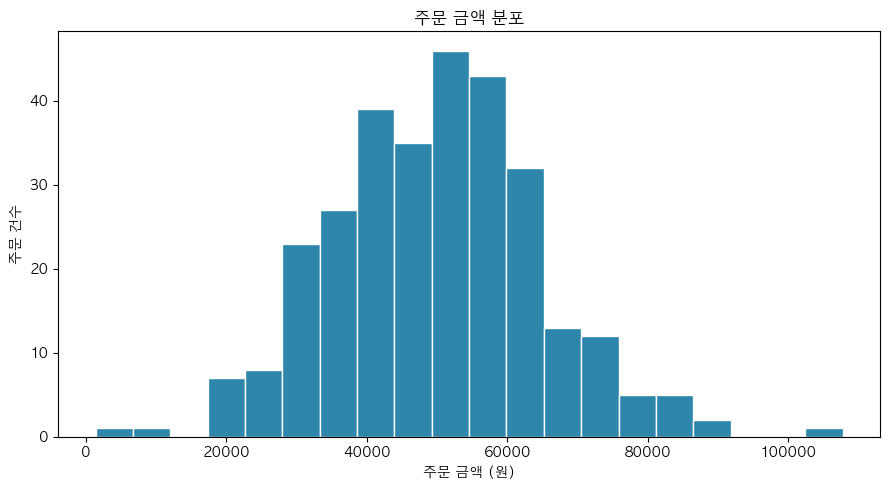

In [1]:
# Basic Syntax: a histogram of order amounts
# 기본 문법: 주문 금액 히스토그램

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
order_amounts = np.random.normal(loc=50000, scale=15000, size=300)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(order_amounts, bins=20, color='#2E86AB', edgecolor='white')
ax.set_title('주문 금액 분포')
ax.set_xlabel('주문 금액 (원)')
ax.set_ylabel('주문 건수')
plt.tight_layout()
plt.show()

## Common Variations · 주요 변형

The `bins` count changes what story the same data tells: too few bins hides real patterns, too many bins turns noise into what looks like a pattern. There's no universal right answer, but starting around 15-30 for a few hundred points and adjusting from there is a reasonable default (or let Matplotlib guess with `bins='auto'`).

`bins` 개수는 같은 데이터도 완전히 다른 인상을 줍니다: 너무 적으면 실제 패턴을 가리고, 너무 많으면 노이즈가 패턴처럼 보입니다. 정해진 정답은 없지만, 데이터가 수백 개면 15~30 정도에서 시작해 조정하는 것이 합리적인 기본값입니다 (또는 `bins='auto'`로 Matplotlib에게 맡길 수 있습니다).

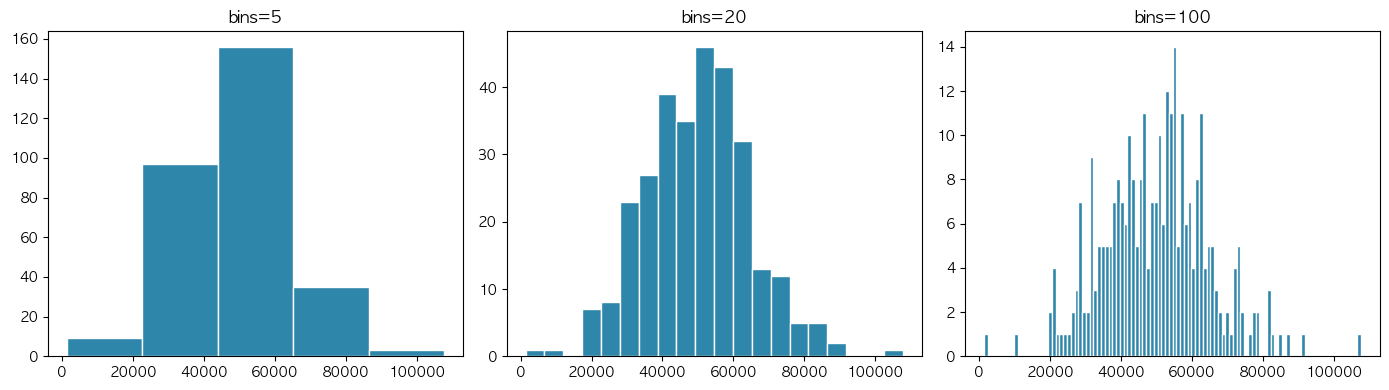

In [2]:
# Common Variations: the same data with 3 different bin counts
# 주요 변형: 같은 데이터를 3가지 다른 bins 값으로

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
data = np.random.normal(loc=50000, scale=15000, size=300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, b in zip(axes, [5, 20, 100]):
    ax.hist(data, bins=b, color='#2E86AB', edgecolor='white')
    ax.set_title(f'bins={b}')
plt.tight_layout()
plt.show()

## KDE (Kernel Density Estimate) · 커널밀도추정

A KDE plot draws the same distribution shape a Histogram shows, but as a smooth curve where the y-axis is *probability density* (the area under the whole curve always sums to 1) instead of a raw count. Because it has no bin edges, it can be easier to compare several groups' shapes on the same axes without bars overlapping and hiding each other.

KDE 플롯은 Histogram이 보여주는 것과 같은 분포 모양을, 원본 개수(count) 대신 y축이 *확률 밀도*(전체 곡선 아래 면적의 합이 항상 1)인 부드러운 곡선으로 그립니다. bin 경계가 없기 때문에, 여러 그룹의 모양을 같은 축에 겹쳐 비교할 때 막대끼리 서로 가리는 문제 없이 더 쉽게 비교할 수 있습니다.

The key parameter is **bandwidth** (`bw_adjust` in Seaborn) — it plays the exact same role for a KDE curve that `bins` plays for a Histogram: too small (narrow bandwidth) and the curve looks noisy and bumpy; too large (wide bandwidth) and it over-smooths, hiding real bumps (modes) in the data.

핵심 파라미터는 **bandwidth**(Seaborn에서는 `bw_adjust`)입니다 — Histogram의 `bins`와 정확히 같은 역할을 합니다: 너무 작으면(좁은 bandwidth) 곡선이 노이즈로 울퉁불퉁해 보이고, 너무 크면(넓은 bandwidth) 지나치게 매끄러워져 데이터의 실제 봉우리(최빈값)를 가릴 수 있습니다.

```python
sns.kdeplot(data=df, x='column')                    # single group
sns.histplot(data=df, x='column', kde=True)          # histogram + KDE overlay together
sns.kdeplot(data=df, x='column', bw_adjust=0.5)      # narrower bandwidth -> more detail/noise
```

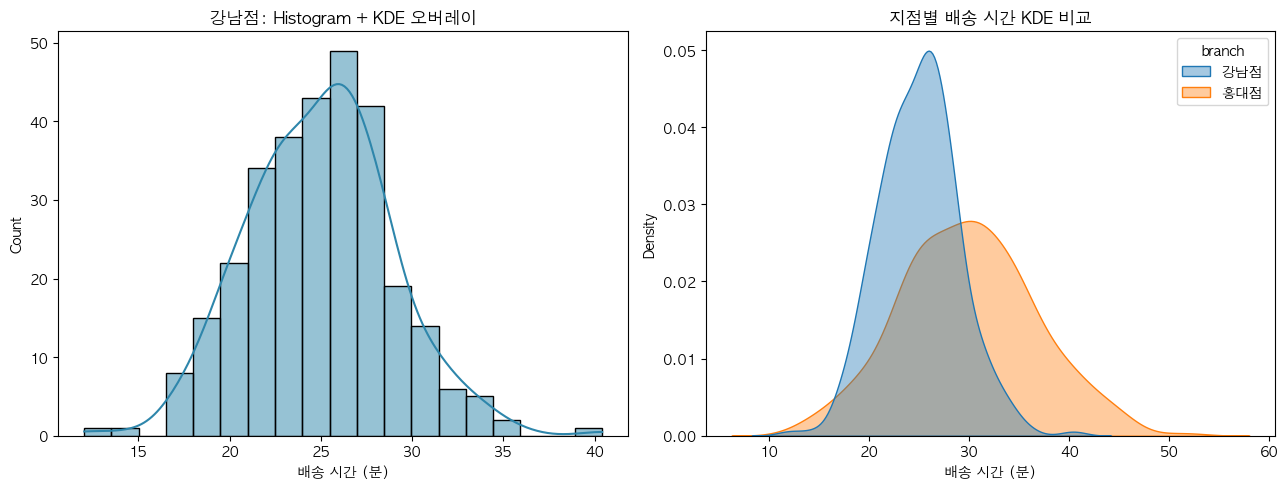

In [3]:
# KDE: comparing two branches' delivery-time shapes without bars hiding each other
# KDE: 막대가 서로 가리지 않게 두 지점의 배송 시간 분포 모양 비교

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
gangnam = np.random.normal(loc=25, scale=4, size=300)
hongdae = np.random.normal(loc=30, scale=7, size=300)
df_kde = pd.concat([
    pd.DataFrame({'delivery_min': gangnam, 'branch': '강남점'}),
    pd.DataFrame({'delivery_min': hongdae, 'branch': '홍대점'}),
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram + KDE overlay for one branch, showing they describe the same shape
# 왼쪽: 한 지점에 대해 histogram과 KDE를 겹쳐 그려 같은 모양을 설명함을 보여줌
sns.histplot(data=gangnam, kde=True, ax=axes[0], color='#2E86AB')
axes[0].set_title('강남점: Histogram + KDE 오버레이')
axes[0].set_xlabel('배송 시간 (분)')

# Right: KDE-only comparison of two groups, no bars to overlap
# 오른쪽: 막대 없이 두 그룹을 KDE만으로 비교
sns.kdeplot(data=df_kde, x='delivery_min', hue='branch', fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('지점별 배송 시간 KDE 비교')
axes[1].set_xlabel('배송 시간 (분)')

plt.tight_layout()
plt.show()

---
# 🧪 Small Examples · 예제

## Example 1: Box Plot — Reading the 5 Numbers & Finding Outliers · 예제 1: Box Plot — 5가지 요약값 읽기 & 이상치 찾기

A Box Plot compresses a distribution into 5 numbers plus outliers: minimum, Q1 (25th percentile), median, Q3 (75th percentile), and maximum — all inside the whisker range.

Box Plot은 분포를 5가지 숫자와 이상치로 압축합니다: 최솟값, Q1(하위 25%), 중앙값, Q3(상위 25%), 그리고 수염(whisker) 범위 안의 최댓값입니다.

```
  ┬     <- whisker top (max within 1.5x IQR) / whisker 끝 (이상치 제외 최댓값)
  │
┌─┴─┐
│   │  <- Q3 (75th percentile) / Q3 (상위 25% 지점)
├───┤  <- median / 중앙값
│   │  <- Q1 (25th percentile) / Q1 (하위 25% 지점)
└─┬─┘
  │
  ┴     <- whisker bottom (min within 1.5x IQR) / whisker 끝 (이상치 제외 최솟값)
  ○     <- outlier / 이상치
```

The outlier fence is calculated from IQR (= Q3 − Q1): anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as an outlier.

이상치 경계는 IQR(= Q3 − Q1)로 계산됩니다: `Q1 - 1.5*IQR`보다 작거나 `Q3 + 1.5*IQR`보다 크면 이상치로 표시됩니다.

⚠️ Note: `boxplot()`'s category-naming parameter was renamed from `labels=` to `tick_labels=` in Matplotlib 3.9. The old `labels=` still runs but raises a `MatplotlibDeprecationWarning` and will eventually be removed — the code below already uses the current `tick_labels=`.

⚠️ 참고: `boxplot()`의 카테고리 이름 지정 파라미터는 Matplotlib 3.9부터 `labels=`에서 `tick_labels=`로 이름이 바뀌었습니다. 예전 `labels=`도 여전히 동작은 하지만 `MatplotlibDeprecationWarning`이 발생하며 향후 제거될 예정입니다 — 아래 코드는 이미 현재 버전인 `tick_labels=`를 사용합니다.

Median / 중앙값: 23.0
Q1: 21.0, Q3: 25.0, IQR: 4.0
Outlier fence / 이상치 경계: 15.0 ~ 31.0
Outliers found / 발견된 이상치: none / 없음



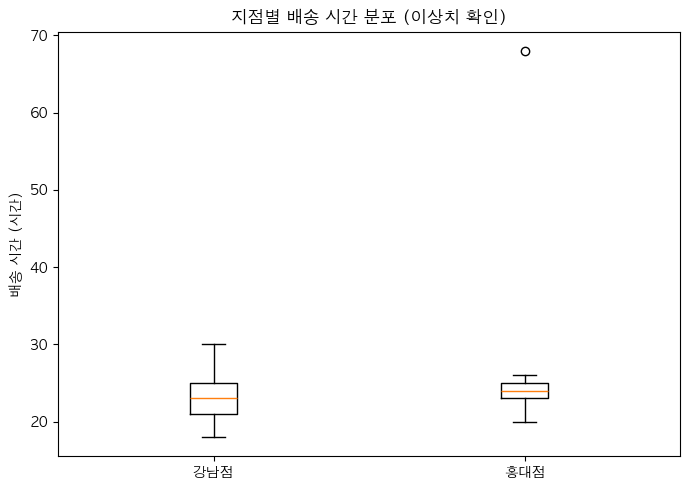

In [4]:
# Example 1: calculate the 5 numbers by hand, then compare two branches visually
# 예제 1: 5가지 요약값을 직접 계산하고, 두 지점을 시각적으로 비교하기

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# a tiny, already-sorted dataset to walk through the math by hand
# 손으로 직접 계산해볼 작고 이미 정렬된 데이터셋
delivery_times = [18, 20, 21, 22, 23, 24, 25, 26, 30]

median = np.median(delivery_times)
q1, q3 = np.percentile(delivery_times, [25, 75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = [v for v in delivery_times if v < lower_fence or v > upper_fence]

print(f"Median / 중앙값: {median}")
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Outlier fence / 이상치 경계: {lower_fence} ~ {upper_fence}")
print(f"Outliers found / 발견된 이상치: {outliers if outliers else 'none / 없음'}")
print()

# now compare two branches, one of which HAS a real outlier
# 이번엔 실제 이상치가 있는 두 지점을 비교
gangnam = [18, 20, 21, 22, 23, 24, 25, 26, 30]
hongdae = [20, 22, 24, 23, 25, 26, 24, 23, 68]   # 68 = a delivery delay outlier

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([gangnam, hongdae], tick_labels=['강남점', '홍대점'])
ax.set_title('지점별 배송 시간 분포 (이상치 확인)')
ax.set_ylabel('배송 시간 (시간)')
plt.tight_layout()
plt.show()

## Example 2: Violin Plot Basics · 예제 2: Violin Plot 기본

A Violin Plot adds the actual density shape on top of everything a Box Plot shows. Note that `violinplot()`, unlike `boxplot()`, has no `tick_labels=` parameter — category labels must be set manually with `set_xticks()` + `set_xticklabels()`.

Violin Plot은 Box Plot이 보여주는 모든 정보 위에 실제 밀도 모양까지 더해서 보여줍니다. `violinplot()`은 `boxplot()`과 달리 `tick_labels=` 파라미터가 없다는 점에 주의하세요 — 카테고리 라벨은 `set_xticks()` + `set_xticklabels()`로 직접 지정해야 합니다.

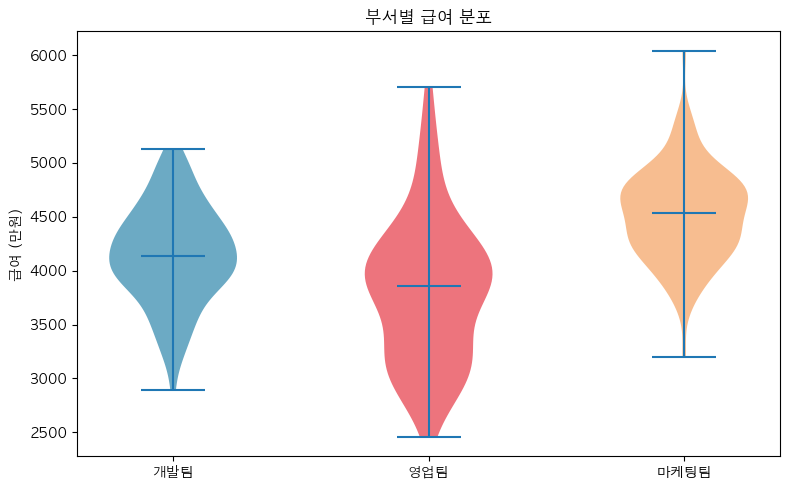

In [5]:
# Example 2: department salary distribution as a violin plot
# 예제 2: 부서별 급여 분포를 violin plot으로

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
dept_a = np.random.normal(loc=4200, scale=500, size=100)
dept_b = np.random.normal(loc=3800, scale=700, size=100)
dept_c = np.random.normal(loc=4500, scale=400, size=100)

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot([dept_a, dept_b, dept_c], showmedians=True)

colors = ['#2E86AB', '#E63946', '#F4A261']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['개발팀', '영업팀', '마케팅팀'])
ax.set_title('부서별 급여 분포')
ax.set_ylabel('급여 (만원)')
plt.tight_layout()
plt.show()

## Example 3: Practice · 예제 3: 연습문제

Three short practices, one per chart type — **Part A** (Histogram) needs a bin count, **Part B** (Box Plot) needs a color, **Part C** (Violin) needs two group labels. Each runs without error either way; the real chart only appears once its own blanks are filled in.

차트 유형별 짧은 연습문제 3개입니다 — **Part A**(Histogram)는 bins 개수, **Part B**(Box Plot)는 색상, **Part C**(Violin)는 그룹 라벨 2개가 필요합니다. 각각 어떤 상태든 에러 없이 실행되며, 해당 빈칸을 채워야만 실제 차트가 나타납니다.

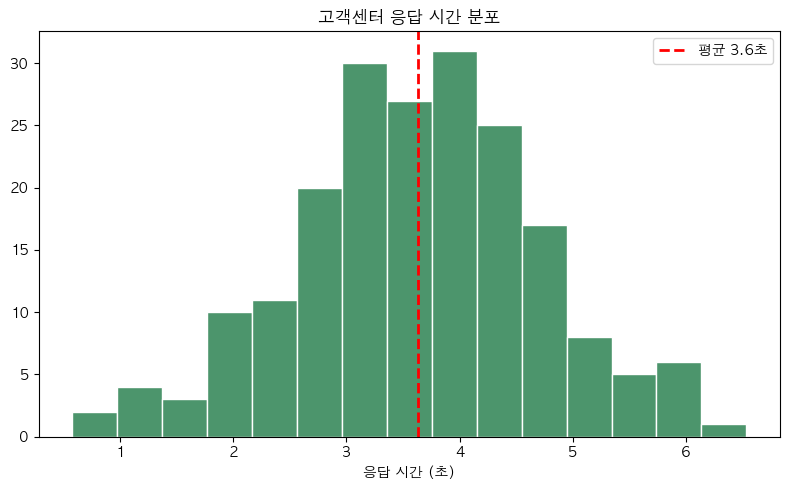

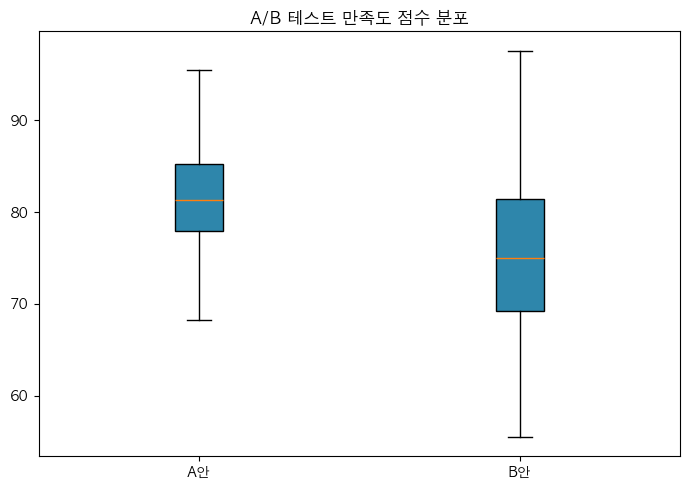

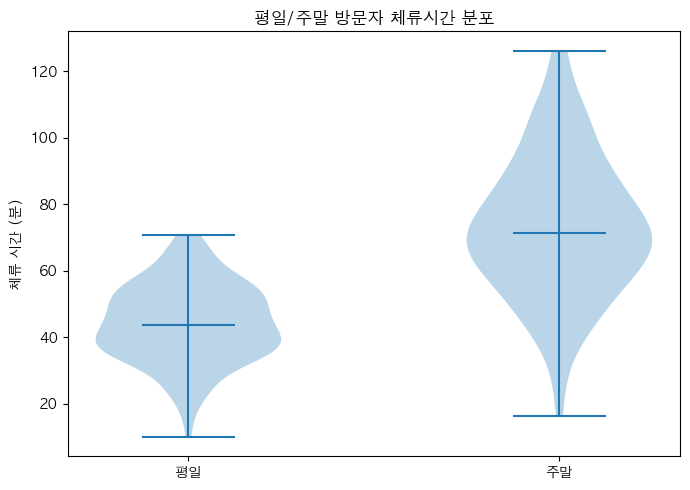

In [9]:
# Practice: fill in the blanks, then re-run this cell
# 연습문제: 빈칸을 채운 후 셀을 다시 실행하세요

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ---- Part A: Histogram of customer service response times ----
# ---- Part A: 고객센터 응답 시간 히스토그램 ----
np.random.seed(1)
response_times = np.random.normal(loc=3.5, scale=1.2, size=200)

bins_count = 15    # TODO: a number, e.g. 15

if bins_count == "________":
    print("Part A: fill in bins_count above, then re-run.")
    print("Part A: 위의 bins_count를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(response_times, bins=bins_count, color='#4C956C', edgecolor='white')
    ax.axvline(response_times.mean(), color='red', linestyle='--', linewidth=2,
               label=f'평균 {response_times.mean():.1f}초')
    ax.set_title('고객센터 응답 시간 분포')
    ax.set_xlabel('응답 시간 (초)')
    ax.legend()
    plt.tight_layout()
    plt.show()

# ---- Part B: Box Plot comparing A/B test satisfaction scores ----
# ---- Part B: A/B 테스트 만족도 점수 Box Plot 비교 ----
np.random.seed(7)
a_group = np.random.normal(loc=82, scale=6, size=80)
b_group = np.random.normal(loc=75, scale=10, size=80)

box_color = "#2E86AB"     # TODO: any valid color, e.g. '#2E86AB'

if box_color == "________":
    print("Part B: fill in box_color above, then re-run.")
    print("Part B: 위의 box_color를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot([a_group, b_group], tick_labels=['A안', 'B안'], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(box_color)
    ax.set_title('A/B 테스트 만족도 점수 분포')
    plt.tight_layout()
    plt.show()

# ---- Part C: Violin Plot comparing weekday/weekend visit duration ----
# ---- Part C: 평일/주말 방문자 체류시간 Violin Plot 비교 ----
np.random.seed(3)
weekday = np.random.normal(loc=45, scale=12, size=150)
weekend = np.random.normal(loc=70, scale=20, size=150)

label_1 = "평일"       # TODO: a label for group 1, e.g. '평일'
label_2 = "주말"       # TODO: a label for group 2, e.g. '주말'

if label_1 == "________" or label_2 == "________":
    print("Part C: fill in label_1 and label_2 above, then re-run.")
    print("Part C: 위의 label_1, label_2를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.violinplot([weekday, weekend], showmedians=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([label_1, label_2])
    ax.set_title('평일/주말 방문자 체류시간 분포')
    ax.set_ylabel('체류 시간 (분)')
    plt.tight_layout()
    plt.show()

---
# ⚠️ Common Mistakes · 자주 하는 실수

### Mistake 1: Never adjusting bins away from the default · 실수 1: bins 기본값을 조정하지 않음

Assuming the default `bins=10` is always fine hides real patterns in larger datasets or exaggerates noise in small ones.

기본값 `bins=10`이 항상 적절하다고 가정하면, 데이터가 클 때는 실제 패턴이 가려지고 작을 때는 노이즈가 패턴처럼 과장됩니다.

✅ **Fix:** Try a few values (like Common Variations above) and pick the one that shows the shape most clearly for your specific data size.  
✅ **해결:** Common Variations처럼 여러 값을 시도해보고, 데이터 크기에 맞게 모양이 가장 잘 보이는 값을 고르세요.

### Mistake 2: Overlaying histograms without alpha · 실수 2: 히스토그램을 겹쳐 그릴 때 alpha 없이 그림

Drawing two histograms on the same Axes without transparency means whichever one is drawn second completely covers the first.

같은 Axes에 두 히스토그램을 투명도 없이 그리면, 나중에 그린 히스토그램이 먼저 그린 것을 완전히 가려버립니다.

✅ **Fix:** Set `alpha=0.5` to `0.7` on both so each remains visible through the other.  
✅ **해결:** 둘 다 `alpha=0.5~0.7` 정도로 설정해 서로 비쳐 보이게 하세요.

### Mistake 2.5: Treating a KDE curve's bandwidth like it's optional · 실수 2.5: KDE의 bandwidth를 신경 쓰지 않고 기본값만 사용

Just like leaving `bins` at its default can mislead a Histogram, leaving a KDE's bandwidth at its automatic default can smooth away a real second peak (bimodal distribution) or, in the opposite direction, make a genuinely smooth distribution look noisy.

Histogram에서 `bins` 기본값을 그대로 두면 오해를 부르는 것처럼, KDE의 bandwidth를 자동 기본값 그대로 두면 실제로 존재하는 두 번째 봉우리(이중 분포)가 뭉개져 사라지거나, 반대로 원래 매끄러운 분포가 노이즈처럼 보일 수 있습니다.

✅ **Fix:** Overlay a Histogram and KDE together (`kde=True`) at least once to sanity-check that the smooth curve isn't hiding or inventing structure the raw bars don't show.  
✅ **해결:** 최소 한 번은 Histogram과 KDE를 함께 겹쳐(`kde=True`) 그려서, 매끄러운 곡선이 원본 막대에 없는 구조를 숨기거나 만들어내고 있지 않은지 확인하세요.

### Mistake 3: Forgetting patch_artist=True to color a Box Plot · 실수 3: patch_artist=True 없이 Box Plot 색 채우기 시도

Calling `.set_facecolor()` on a box does nothing (and raises no error) unless `patch_artist=True` was passed to `boxplot()` in the first place.

`boxplot()`을 호출할 때애 `patch_artist=True`를 넘기지 않으면, 상자에 `.set_facecolor()`를 호출해도 아무 효과가 없습니다 (에러도 나지 않습니다).

✅ **Fix:** Always pass `patch_artist=True` to `boxplot()` whenever you plan to color the boxes.  
✅ **해결:** 상자에 색을 채울 계획이라면 항상 `boxplot()`에 `patch_artist=True`를 함께 넘기세요.

### Mistake 4: Assuming a Box Plot alone proves a single peak · 실수 4: Box Plot만으로 "봉우리가 하나"라고 단정

A Box Plot can look completely normal — clean quartiles, no flagged outliers — even when the underlying data actually has two separate peaks, because it only reports 5 summary numbers, not the shape.

Box Plot은 사분위수도 깔끔하고 이상치도 없어 보일 수 있지만, 실제로는 데이터에 봉우리가 두 개 있을 수도 있습니다 — 5가지 요약값만 알려줄 뿐 모양 자체는 보여주지 않기 때문입니다.

✅ **Fix:** When a Box Plot's spread looks unusually wide for no clear reason, double-check with a Violin Plot before assuming the group is homogeneous.  
✅ **해결:** Box Plot의 폭이 특별한 이유 없이 유독 넓어 보인다면, 그 그룹이 균일하다고 단정하기 전에 Violin Plot으로 다시 확인하세요.

### Mistake 5: Passing tick_labels= to violinplot() · 실수 5: violinplot()에 tick_labels= 전달

Unlike `boxplot()`, `violinplot()` doesn't accept a `tick_labels=` (or `labels=`) argument at all — passing one raises a `TypeError`.

`boxplot()`과 달리 `violinplot()`은 `tick_labels=`(또는 `labels=`) 인자를 아예 받지 않습니다 — 전달하면 `TypeError`가 발생합니다.

✅ **Fix:** Label a violin plot's x-axis manually with `ax.set_xticks([1,2,3])` followed by `ax.set_xticklabels([...])`, exactly like Example 2 above.  
✅ **해결:** 위 Example 2처럼 `ax.set_xticks([1,2,3])`과 `ax.set_xticklabels([...])`로 직접 라벨을 붙이세요.

### Mistake 6: Using a Violin Plot on too few data points · 실수 6: 표본이 매우 적은데 Violin Plot 사용

With only a handful of points (say, 5), the density curve a Violin Plot draws is a statistical guess that can look smooth and confident while being essentially meaningless.

표본이 5개 정도로 매우 적으면, Violin Plot이 그리는 밀도 곡선은 부드럽고 그럴듯해 보여도 사실상 의미 없는 통계적 추정치일 수 있습니다.

✅ **Fix:** For very small samples, a Box Plot or a simple strip of dots is more honest than a Violin Plot's smoothed curve.   
✅ **해결:** 표본이 매우 적을 때는 Violin Plot의 부드러운 곡선보다 Box Plot이나 단순한 점 나열이 더 정직한 표현입니다.

---
# 💡 Tips · 팁
Useful tips or shortcuts · 유용한 팁과 지름길

- Start with `bins='auto'` or try a few counts side by side before committing — the right value depends on your data size, not a fixed rule.  
확정하기 전에 `bins='auto'`로 시작하거나 몇 가지 값을 나란히 시도해보세요 — 정해진 규칙이 아니라 데이터 크기에 따라 다릅니다.
- When overlaying 2+ histograms for comparison, always set `alpha=0.5-0.7` so neither one fully hides the other.  
히스토그램 2개 이상을 겹쳐 비교할 때는 항상 `alpha=0.5~0.7`을 설정해 서로 가리지 않게 하세요.
- When comparing 2+ groups' shapes, reach for `sns.kdeplot(..., hue=...)` instead of overlapping histograms — smooth curves are far easier to compare than semi-transparent bars.  
그룹 2개 이상의 모양을 비교할 때는 히스토그램을 겹치는 대신 `sns.kdeplot(..., hue=...)`을 쓰세요 — 부드러운 곡선이 반투명 막대보다 훨씬 비교하기 쉽습니다.
- Treat Histogram -> KDE -> Box Plot -> Violin Plot as an escalation path: start simple, and reach for the next one only when you suspect the simpler chart is hiding something.  
Histogram -> Box Plot -> Violin Plot을 단계적 확장 경로로 취급하세요: 단순하게 시작하고, 더 단순한 차트가 뭔가를 숨기고 있다고 의심될 때만 다음 단계로 넘어가세요.
- A Violin Plot needs a reasonably large sample to be trustworthy — with very few points, prefer a Box Plot or plain dots instead.  
Violin Plot이 신뢰할 만하려면 표본이 충분히 커야 합니다 — 표본이 매우 적다면 Box Plot이나 단순 점 표시를 쓰세요.

---
# 🔗 Related Concepts · 관련 개념

```
   Section 4: Bar Chart   (purpose: Comparison, unordered categories)
                ↓
   Section 5: Distribution Charts   ←  YOU ARE HERE / 지금 여기
   (purpose: Distribution - "how is one variable spread out")
   Histogram -> KDE -> Box Plot -> Violin Plot  (escalating detail)
                ↓
   Section 6: Relationship Charts (Scatter / Bubble)
                ↓
   Sections 7-8: Ratio / Composite charts
```

*How is today's topic connected to other concepts?* · *오늘 배운 내용이 다른 개념과 어떻게 연결되는가?*

This section directly answers Section 1's "Distribution" purpose row, and the 3 chart types form a deliberate escalation: Histogram for a first look, Box Plot to compress and compare many groups at once, Violin Plot when you suspect a simpler chart might be hiding real structure — exactly what happened with the Gold-tier customers in the Business Example below. This same "start simple, escalate only when needed" instinct comes back explicitly in Section 8, where a Heatmap's correlation number is deliberately paired with more detailed charts to check what the number alone doesn't show.

이 섹션은 섹션 1의 "분포" 행에 대한 직접적인 답이며, 3가지 차트는 의도적인 단계적 확장을 이룹니다: 처음엔 Histogram으로 훑어보고, 여러 그룹을 한 번에 압축 비교하려면 Box Plot, 더 단순한 차트가 진짜 구조를 숨기고 있다고 의심되면 Violin Plot — 바로 아래 비즈니스 예제의 골드 등급 고객에게 실제로 일어난 일입니다. "단순하게 시작하고 필요할 때만 확장한다"는 이 감각은 섹션 8에서 Heatmap의 상관계수 숫자를 더 상세한 차트와 의도적으로 짝지어 숫자만으로는 안 보이는 것을 확인할 때 다시 명시적으로 등장합니다.

---
# 💼 Business Example · 비즈니스 예제
*How would a Business Analyst use this?* · *비즈니스 분석가는 이것을 어떻게 활용할까?*

**Scenario / 시나리오:**
Your company has 3 customer tiers: VIP, Gold, Silver. Average monthly spend per tier looks perfectly reasonable — but your manager asks you to double-check the Gold tier specifically, since retention there has been oddly inconsistent.

회사에 VIP·골드·실버 3개 고객 등급이 있습니다. 등급별 평균 월 구매액은 지극히 합리적으로 보이지만, 매니저가 특히 골드 등급의 리텐션이 이상하게 들쭉날쭉하다며 다시 확인해달라고 요청합니다.

**To-Do / 할 일:**
- [x] Plot the monthly spend distribution for all 3 tiers as Violin Plots, not just Box Plots  
3개 등급의 월 구매액 분포를 Box Plot이 아닌 Violin Plot으로 그리기
- [x] Look for any tier whose violin shows two humps instead of one  
봉우리가 하나가 아니라 두 개인 등급이 있는지 확인하기
- [x] Turn the visual finding into a concrete, actionable recommendation  
시각적 발견을 구체적이고 실행 가능한 제안으로 전환하기

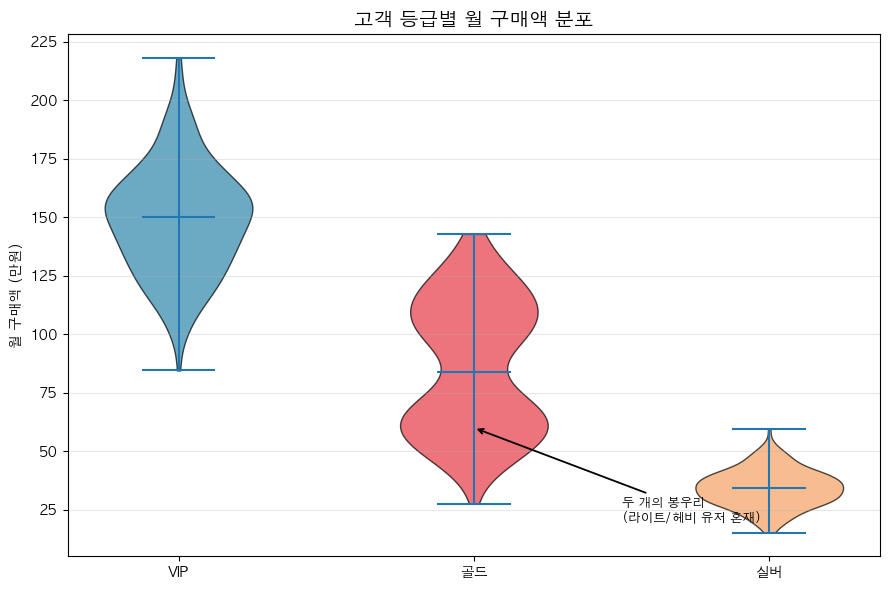

VIP mean / 평균: 149
Gold mean / 평균: 86  <- looks like one group, but is it? / 단일 그룹처럼 보이지만 정말 그럴까?
Silver mean / 평균: 34

A Box Plot would only have shown the median and quartiles here - it would NOT have revealed the two humps.
Box Plot이었다면 중앙값과 사분위수만 보여줬을 뿐, 이 두 개의 봉우리는 드러내지 못했을 것입니다.
Recommendation: split 'Gold' into 'Gold-Light' and 'Gold-Heavy' and target each with different messaging.
제안: '골드'를 '골드-라이트'와 '골드-헤비'로 세분화하고 각각 다른 마케팅 메시지를 적용할 것.


In [10]:
# Business Example: discovering a hidden bimodal distribution in the Gold tier
# 비즈니스 예제: 골드 등급에 숨겨진 이중 분포 발견하기

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
vip = np.random.normal(loc=150, scale=25, size=200)
# "Gold" secretly contains two different customer types: light users and heavy users
# "골드" 등급은 사실 성격이 다른 두 그룹(라이트/헤비 유저)이 섞여 있음
gold_light = np.random.normal(loc=60, scale=10, size=100)
gold_heavy = np.random.normal(loc=110, scale=15, size=100)
gold = np.concatenate([gold_light, gold_heavy])
silver = np.random.normal(loc=35, scale=8, size=200)

data = [vip, gold, silver]
tiers = ['VIP', '골드', '실버']

fig, ax = plt.subplots(figsize=(9, 6))
parts = ax.violinplot(data, showmedians=True, showextrema=True)

colors = ['#2E86AB', '#E63946', '#F4A261']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(tiers)
ax.set_title('고객 등급별 월 구매액 분포', fontsize=14, fontweight='bold')
ax.set_ylabel('월 구매액 (만원)')
ax.grid(True, alpha=0.3, axis='y')

ax.annotate('두 개의 봉우리\n(라이트/헤비 유저 혼재)', xy=(2, 60), xytext=(2.5, 20),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.3), fontsize=9)

plt.tight_layout()
# fig.savefig('customer_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"VIP mean / 평균: {vip.mean():.0f}")
print(f"Gold mean / 평균: {gold.mean():.0f}  <- looks like one group, but is it? / 단일 그룹처럼 보이지만 정말 그럴까?")
print(f"Silver mean / 평균: {silver.mean():.0f}")
print()
print("A Box Plot would only have shown the median and quartiles here - it would NOT have revealed the two humps.")
print("Box Plot이었다면 중앙값과 사분위수만 보여줬을 뿐, 이 두 개의 봉우리는 드러내지 못했을 것입니다.")
print("Recommendation: split 'Gold' into 'Gold-Light' and 'Gold-Heavy' and target each with different messaging.")
print("제안: '골드'를 '골드-라이트'와 '골드-헤비'로 세분화하고 각각 다른 마케팅 메시지를 적용할 것.")

---
# 📝 Summary · 요약
*Write today's concept in 3~5 sentences.* · *오늘 배운 개념을 3~5문장으로 정리하세요.*

Histogram, KDE, Box Plot, and Violin Plot all show how a single numeric variable is spread out, but at increasing levels of detail: a Histogram groups values into bins for an intuitive first look, a KDE plot smooths that same shape into a continuous density curve (controlled by bandwidth instead of bins), a Box Plot compresses everything into 5 summary numbers plus IQR-based outliers so several groups fit on one screen, and a Violin Plot adds the actual density shape on top of everything a Box Plot shows. The `bins` count you choose for a Histogram (or the bandwidth for a KDE) can make the same data look completely different, and `boxplot()`/`violinplot()` differ in one key syntax detail — only `boxplot()` accepts `tick_labels=`. The most valuable habit from this section is treating the four charts as an escalation path: start with the simplest one, and only escalate when you suspect it might be hiding real structure, exactly as happened with the "Gold tier" in the Business Example. Outliers flagged by a Box Plot aren't automatically bad data — they deserve investigation before being removed.

Histogram, KDE, Box Plot, Violin Plot은 모두 하나의 수치형 변수가 어떻게 퍼져 있는지 보여주지만, 디테일 수준이 점점 높아집니다: Histogram은 값을 구간으로 나눠 직관적인 첫인상을 주고, KDE 플롯은 같은 모양을(bins 대신 bandwidth로 조절되는) 매끄러운 연속 밀도 곡선으로 다듬으며, Box Plot은 이를 5가지 요약값과 IQR 기반 이상치로 압축해 여러 그룹을 한 화면에 담고, Violin Plot은 Box Plot이 보여주는 모든 것 위에 실제 밀도 모양까지 더합니다. Histogram의 `bins` 개수(또는 KDE의 bandwidth)는 같은 데이터를 완전히 다르게 보이게 만들 수 있고, `boxplot()`/`violinplot()`은 문법상 한 가지 핵심 차이가 있습니다 — `tick_labels=`는 `boxplot()`에서만 받습니다. 이 섹션에서 가장 값진 습관은 네 차트를 단계적 확장 경로로 다루는 것입니다: 가장 단순한 것부터 시작하고, 뭔가를 숨기고 있다고 의심될 때만 확장하세요 — 비즈니스 예제의 "골드 등급"에서 실제로 일어난 일처럼요. Box Plot이 표시하는 이상치가 자동으로 "나쁜 데이터"인 것은 아니며, 제거하기 전에 조사해볼 가치가 있습니다.

---
# 📌 One Sentence Summary · 한 줄 요약
Today's topic in ONE sentence. · 오늘의 주제를 한 문장으로.

> Histogram, Box Plot, and Violin Plot are the same question — "how is this spread out?" — asked with increasing detail, so start with the simplest one and escalate only when you suspect it's hiding real structure.

> Histogram, Box Plot, Violin Plot은 "이것이 어떻게 퍼져 있는가?"라는 같은 질문을 점점 더 자세히 묻는 것이므로, 가장 단순한 것부터 시작하고 진짜 구조를 숨기고 있다고 의심될 때만 확장하라.

---
# ❓ Review Questions · 복습 문제

**Q1.** What does changing the `bins` count on a Histogram actually change, and why is there no single "correct" value?  
Histogram의 `bins` 개수를 바꾸면 실제로 무엇이 바뀌며, 왜 정해진 "정답" 값이 없는가?

t changes how coarse or fine the shape looks. Too few bins hide real peaks; too many turn noise into fake peaks, so no one number always works.  
bins는 구간을 얼마나 잘게 자를지입니다. 적으면 패턴이 가려지고 많으면 노이즈가 패턴처럼 보여서 정답이 없습니다.

**Q2.** List the 5 numbers a Box Plot displays, and explain how the IQR-based outlier fence is calculated.  
Box Plot이 보여주는 5가지 숫자를 나열하고, IQR 기반 이상치 경계가 어떻게 계산되는지 설명하라.

The 5 numbers are min, Q1, median, Q3, and max. The fence is Q1 − 1.5×IQR and Q3 + 1.5×IQR.  
5개는 최솟값, Q1, 중앙값, Q3, 최댓값입니다. 경계는 Q1−1.5×IQR, Q3+1.5×IQR입니다.

**Q2.5.** What role does bandwidth play for a KDE plot, and which Histogram parameter is it directly analogous to?  
KDE 플롯에서 bandwidth는 어떤 역할을 하며, Histogram의 어떤 파라미터와 직접 대응되는가?

Bandwidth controls how smooth the KDE curve is — the same job bins does for a Histogram.  
bandwidth는 KDE를 얼마나 매끄럽게 할지이며, Histogram의 bins와 같습니다.

**Q3.** Why can a Box Plot look completely normal even when the underlying data has two separate peaks?  
데이터에 봉우리가 두 개 있는데도 Box Plot이 완전히 정상적으로 보일 수 있는 이유는 무엇인가?

A Box Plot only shows 5 summaries, not density shape, so two peaks can still look like one normal box.  
Box Plot은 모양 없이 요약값만 보여서, 쌍봉이어도 평범한 상자처럼 보일 수 있습니다.

**Q4.** What key syntax difference exists between `boxplot()` and `violinplot()` regarding category labels?  
카테고리 라벨과 관련해 `boxplot()`과 `violinplot()` 사이에 어떤 핵심 문법 차이가 있는가?

boxplot() takes tick_labels=; violinplot() does not — set ticks and labels by hand.  
boxplot()만 tick_labels=를 받고, violinplot()은 직접 라벨을 지정합니다.

**Q5.** In the Business Example, why was a Violin Plot able to reveal something a Box Plot would have missed about the Gold tier?  
비즈니스 예제에서, Violin Plot이 골드 등급에 대해 Box Plot이 놓쳤을 무언가를 드러낼 수 있었던 이유는 무엇인가?

The Gold violin showed two humps (light vs heavy spenders) that a Box Plot would compress into one ordinary-looking box.  
골드는 가벼운 고객과 헤비 고객이 섞여 쌍봉인데, Box Plot은 그걸 한 상자로 압축해 놓칩니다.

---
*📅 Try answering these again in a few days.* · *📅 며칠 후에 다시 답해보세요.*